# Winner Plc — Testing for Salary Discrimination

## Introduction

At the last board meeting of **Winner Plc**, concerns were raised that women executives were being underpaid relative to men — on average by about £8,400. This notebook investigates whether this gap is statistically significant, and whether it is explained by differences in **experience** or represents genuine **gender-based discrimination**.

The dataset contains salaries for a sample of 50 executives (24 men, 26 women).

In [87]:
# --- Import libraries ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# scipy.stats gives us statistical tests like the t-test
from scipy import stats

# statsmodels is used for regression modelling (like lm() in R)
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


from patsy import dmatrix
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [88]:
# --- Load the Winner Plc data ---
winner =  pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/data_analytics_executives/main/data/Winner.csv")


print('Shape:', winner.shape)
print('\nColumn types:')
print(winner.dtypes)
print('\nFirst few rows:')
winner.head()

Shape: (50, 4)

Column types:
employee      int64
gender          str
experience    int64
salary        int64
dtype: object

First few rows:


,employee,gender,experience,salary
0,1,male,16,79400
1,2,male,25,67400
2,3,male,15,66500
3,4,male,33,72600
4,5,male,16,63600


---
## 1. Salary on Gender

Can we conclude that there is a **significant difference** between male and female salaries?

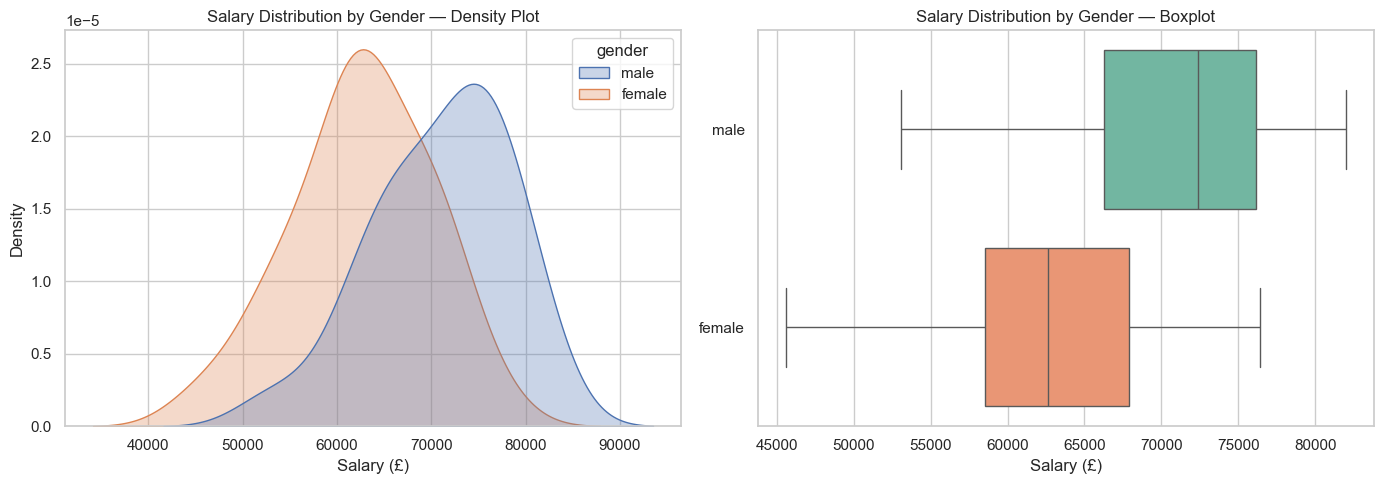

In [89]:
# --- Visualise salary distributions by gender ---
# Left panel: density plot (smoothed histogram)
# Right panel: horizontal boxplot
# Remember: the line in the middle of a boxplot is the MEDIAN, not the mean

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Density plot
sns.kdeplot(
    data=winner, x='salary', hue='gender',
    fill=True, alpha=0.3, ax=axes[0]
)
axes[0].set_title('Salary Distribution by Gender — Density Plot')
axes[0].set_xlabel('Salary (£)')

# Horizontal boxplot
sns.boxplot(
    data=winner, x='salary', y='gender',
    hue='gender', palette='Set2',
    legend=False, ax=axes[1]
)
axes[1].set_title('Salary Distribution by Gender — Boxplot')
axes[1].set_xlabel('Salary (£)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [90]:
# --- Summary statistics by gender ---
# Equivalent to mosaic::favstats(salary ~ gender) in R
# We also compute the standard error: SE = SD / sqrt(n)

(
    winner
    .groupby('gender')['salary']
    .agg(['count', 'min', 'median', 'mean', 'max', 'std'])
    .assign(se=lambda df: df['std'] / np.sqrt(df['count']))
    .round(2)
    .rename(columns={'count': 'n'})
)

,n,min,median,mean,max,std,se
gender,,,,,,,
female,26,45600,62650.0000,62576.9200,76400,7336.7700,1438.8600
male,24,53100,72400.0000,71008.3300,82000,7235.2900,1476.9000


### Confidence Intervals

We can construct CIs 'by hand' using the t-distribution critical values. The t-critical value depends on the sample size and confidence level.

In [91]:
# --- t-critical values for manual CI construction ---
# Equivalent to qt(0.975, 23) and qt(0.975, 25) in R
# n_male = 24  → df = 23
# n_female = 26 → df = 25

for label, df in [('Male (n=24)', 23), ('Female (n=26)', 25)]:
    t95  = stats.t.ppf(0.975, df=df)
    t99  = stats.t.ppf(0.995, df=df)
    t999 = stats.t.ppf(0.9995, df=df)
    print(f'{label}:')
    print(f'  95%  CI t-critical : {t95:.4f}')
    print(f'  99%  CI t-critical : {t99:.4f}')
    print(f'  99.9% CI t-critical: {t999:.4f}')
    print()

Male (n=24):
  95%  CI t-critical : 2.0687
  99%  CI t-critical : 2.8073
  99.9% CI t-critical: 3.7676

Female (n=26):
  95%  CI t-critical : 2.0595
  99%  CI t-critical : 2.7874
  99.9% CI t-critical: 3.7251



In [92]:
def two_sample_ttest_summary(a, b, col, label_a, label_b):
    x, y = a[col].dropna(), b[col].dropna()
    t, p = stats.ttest_ind(x, y, equal_var=False)  # Welch's
    df_w = (x.var()/len(x) + y.var()/len(y))**2 / (
            (x.var()/len(x))**2/(len(x)-1) + (y.var()/len(y))**2/(len(y)-1))
    diff = x.mean() - y.mean()
    se   = np.sqrt(x.var()/len(x) + y.var()/len(y))
    ci   = stats.t.interval(0.95, df=df_w, loc=diff, scale=se)

    print(f"--- Welch Two-Sample T-Test: {col} | {label_a} vs {label_b} ---")
    print(f"  n         : {len(x)}  vs  {len(y)}")
    print(f"  mean      : {x.mean():,.2f}  vs  {y.mean():,.2f}")
    print(f"  std       : {x.std(ddof=1):,.2f}  vs  {y.std(ddof=1):,.2f}")
    print(f"  diff      : {diff:,.2f}  ({label_a} minus {label_b})")
    print(f"  95% CI    : [{ci[0]:,.2f}, {ci[1]:,.2f}]")
    print(f"  t         : {t:.4f}")
    print(f"  df        : {df_w:.2f}")
    print(f"  p-value   : {p:.6f}  {'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'}")


In [93]:

two_sample_ttest_summary(
    winner.loc[winner['gender'] == 'male'],
    winner.loc[winner['gender'] == 'female'],
    col='salary',
    label_a='Male', label_b='Female'
)

--- Welch Two-Sample T-Test: salary | Male vs Female ---
  n         : 24  vs  26
  mean      : 71,008.33  vs  62,576.92
  std       : 7,235.29  vs  7,336.77
  diff      : 8,431.41  (Male minus Female)
  95% CI    : [4,285.13, 12,577.69]
  t         : 4.0891
  df        : 47.78
  p-value   : 0.000165  ***


In [94]:
def fit_and_plot(formula, data, model_name="Model", x_var=None):
    model = smf.ols(formula=formula, data=data).fit()

    # ── Compact summary ───────────────────────────────────────────────────────
    rse = np.sqrt(model.mse_resid)
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  R²: {model.rsquared:.4f}    Adj R²: {model.rsquared_adj:.4f}    Residual SE: {rse:.4f}")
    print(f"  Observations: {int(model.nobs)}    df residual: {int(model.df_resid)}")
    print(f"{'-'*55}")
    print(f"  {'Coefficient':<20} {'Estimate':>10} {'Std Err':>10} {'t':>8} {'P>|t|':>8}")
    print(f"{'-'*55}")
    for name, coef, se, tval, pval in zip(
        model.params.index,
        model.params,
        model.bse,
        model.tvalues,
        model.pvalues
    ):
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "." if pval < 0.1 else ""
        print(f"  {name:<20} {coef:>10.4f} {se:>10.4f} {tval:>8.3f} {pval:>8.4f} {sig}")
    print(f"{'='*55}\n")

    if x_var is None:
        x_var = formula.split('~')[1].strip().split('+')[0].strip()

    y_var     = formula.split('~')[0].strip()
    residuals = model.resid
    is_cat    = data[x_var].dtype == object or str(data[x_var].dtype) == 'category'

    fig = plt.figure(figsize=(15, 10))
    gs  = fig.add_gridspec(2, 2, height_ratios=[1.6, 1], hspace=0.35, wspace=0.3)
    ax_main = fig.add_subplot(gs[0, :])
    ax_res  = fig.add_subplot(gs[1, 0])
    ax_qq   = fig.add_subplot(gs[1, 1])

    # ── 1. Actual vs Predicted ────────────────────────────────────────────────
    if is_cat:
        sns.stripplot(x=data[x_var], y=data[y_var],
                      alpha=0.3, color='black', s=4, ax=ax_main, label='Actual')
        group_means = data.groupby(x_var)[y_var].mean()
        ax_main.hlines(group_means.values,
                       xmin=[i - 0.3 for i in range(len(group_means))],
                       xmax=[i + 0.3 for i in range(len(group_means))],
                       colors='red', linewidth=2, label='Predicted mean')
    else:
        ax_main.scatter(data[x_var], data[y_var],
                        alpha=0.3, color='black', s=15, label='Actual')
        ax_main.scatter(data[x_var], model.fittedvalues,
                        alpha=0.3, color='red', s=15, label='Predicted')

    ax_main.set_title(f'Actual vs Predicted — x: {x_var}', fontsize=13)
    ax_main.set_xlabel(x_var)
    ax_main.set_ylabel(y_var)
    ax_main.legend()

    # ── 2. Residuals vs Fitted ────────────────────────────────────────────────
    ax_res.scatter(model.fittedvalues, residuals,
                   alpha=0.3, color='steelblue', s=15)
    ax_res.axhline(0, color='red', linewidth=1, linestyle='--')
    ax_res.set_title('Residuals vs Fitted', fontsize=11)
    ax_res.set_xlabel('Fitted Values')
    ax_res.set_ylabel('Residuals')

    # ── 3. Q-Q plot ───────────────────────────────────────────────────────────
    (osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist='norm')
    ax_qq.scatter(osm, osr, alpha=0.3, color='steelblue', s=15)
    ax_qq.plot(osm, slope * np.array(osm) + intercept,
               color='red', linewidth=1, linestyle='--')
    ax_qq.set_title('Q-Q Plot of Residuals', fontsize=11)
    ax_qq.set_xlabel('Theoretical Quantiles')
    ax_qq.set_ylabel('Sample Quantiles')

    # ── Suptitle with all three stats ─────────────────────────────────────────
    plt.suptitle(
        f'{model_name}  |  R² = {model.rsquared:.3f}  |  Adj R² = {model.rsquared_adj:.3f}  |  Residual SE = {rse:.3f}',
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.show()

    return model


  Salary ~ Gender
  R²: 0.2581    Adj R²: 0.2427    Residual SE: 7288.3247
  Observations: 50    df residual: 48
-------------------------------------------------------
  Coefficient            Estimate    Std Err        t    P>|t|
-------------------------------------------------------
  Intercept            62576.9231  1429.3581   43.780   0.0000 ***
  gender[T.male]        8431.4103  2063.1007    4.087   0.0002 ***



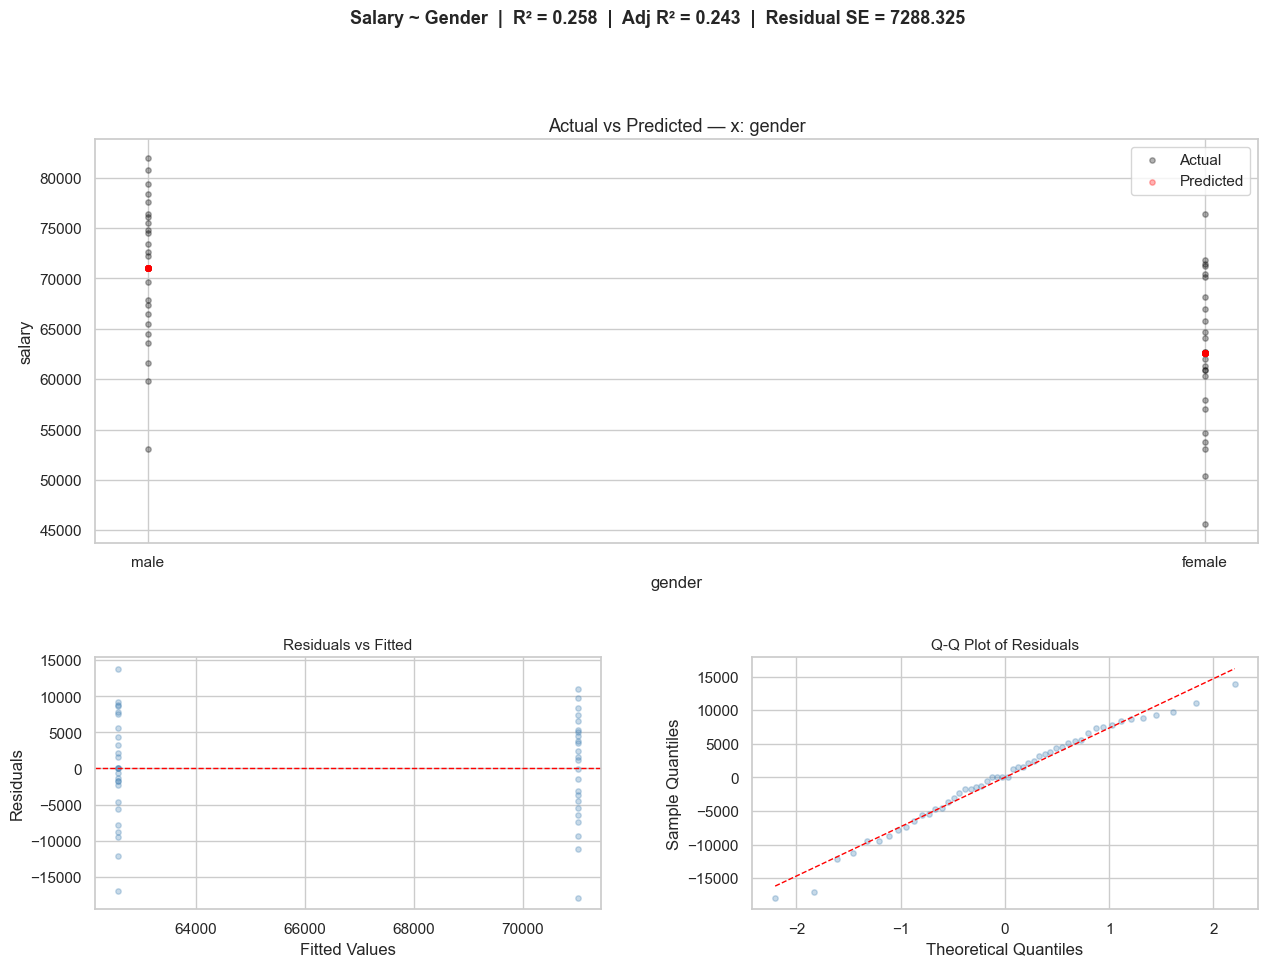

In [95]:
# --- Regression: salary ~ gender ---
# The slope on 'genderMale' is the mean salary difference between men and women.
# Compare it with the observed difference above — they should be identical!

model1 = fit_and_plot('salary ~ gender', 
                    data=winner, 
                    model_name='Salary ~ Gender', 
                    x_var='gender')


---
## 2. Experience on Gender

At the board meeting, someone suggested that the salary gap might reflect **differences in experience** rather than discrimination. Men in the sample have ~21 years experience on average vs ~7 years for women.

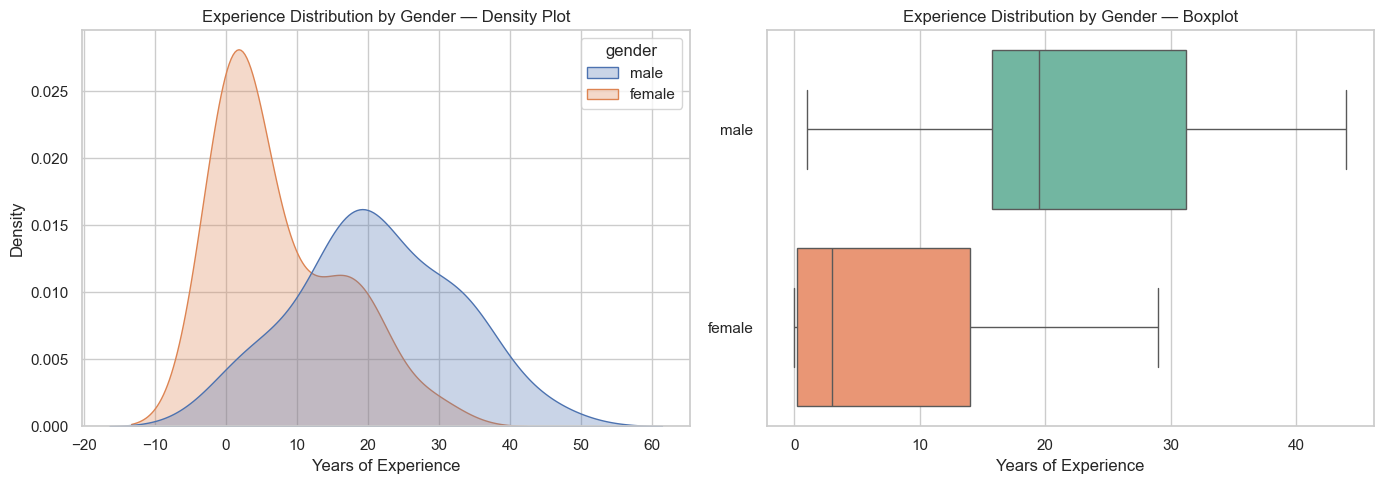

In [96]:
# --- Visualise experience distributions by gender ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(
    data=winner, x='experience', hue='gender',
    fill=True, alpha=0.3, ax=axes[0]
)
axes[0].set_title('Experience Distribution by Gender — Density Plot')
axes[0].set_xlabel('Years of Experience')

sns.boxplot(
    data=winner, x='experience', y='gender',
    hue='gender', palette='Set2',
    legend=False, ax=axes[1]
)
axes[1].set_title('Experience Distribution by Gender — Boxplot')
axes[1].set_xlabel('Years of Experience')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [97]:
# --- Summary statistics: experience by gender ---

(
    winner
    .groupby('gender')['experience']
    .agg(['count', 'min', 'median', 'mean', 'max', 'std'])
    .assign(se=lambda df: df['std'] / np.sqrt(df['count']))
    .round(2)
    .rename(columns={'count': 'n'})
)

,n,min,median,mean,max,std,se
gender,,,,,,,
female,26,0,3.0000,7.3800,29,8.5100,1.6700
male,24,1,19.5000,21.1200,44,10.9200,2.2300


In [98]:
# --- t-test: is the experience gap between genders significant? ---
# If experience differs significantly AND experience drives salary,
# the salary gap may be explained by experience rather than discrimination.

two_sample_ttest_summary(
    winner.loc[winner['gender'] == 'male'],
    winner.loc[winner['gender'] == 'female'],
    col='experience',
    label_a='Male', label_b='Female'
)

--- Welch Two-Sample T-Test: experience | Male vs Female ---
  n         : 24  vs  26
  mean      : 21.12  vs  7.38
  std       : 10.92  vs  8.51
  diff      : 13.74  (Male minus Female)
  95% CI    : [8.13, 19.35]
  t         : 4.9348
  df        : 43.47
  p-value   : 0.000012  ***


---
## 3. Salary on Experience

We now examine the direct relationship between salary, experience, and gender.

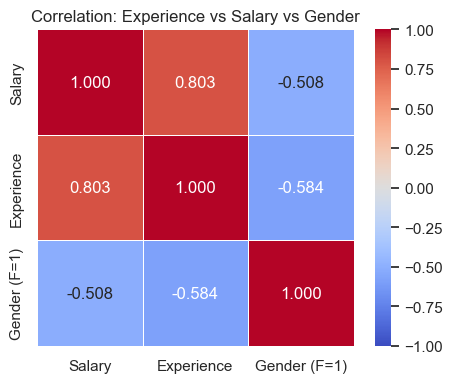

In [99]:


winner['gender_num'] = (winner['gender'] == 'female').astype(int)

corr = winner[['salary','experience',  'gender_num']].corr()
corr.index   = ['Salary','Experience',  'Gender (F=1)']
corr.columns = ['Salary', 'Experience', 'Gender (F=1)']


fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    corr,
    annot=True, fmt='.3f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    ax=ax
)


ax.set_title('Correlation: Experience vs Salary vs Gender')
plt.tight_layout()
plt.show()


  Salary ~ Experience
  R²: 0.6451    Adj R²: 0.6377    Residual SE: 5041.3443
  Observations: 50    df residual: 48
-------------------------------------------------------
  Coefficient            Estimate    Std Err        t    P>|t|
-------------------------------------------------------
  Intercept            58704.7613  1107.8104   52.992   0.0000 ***
  experience             566.4691    60.6512    9.340   0.0000 ***



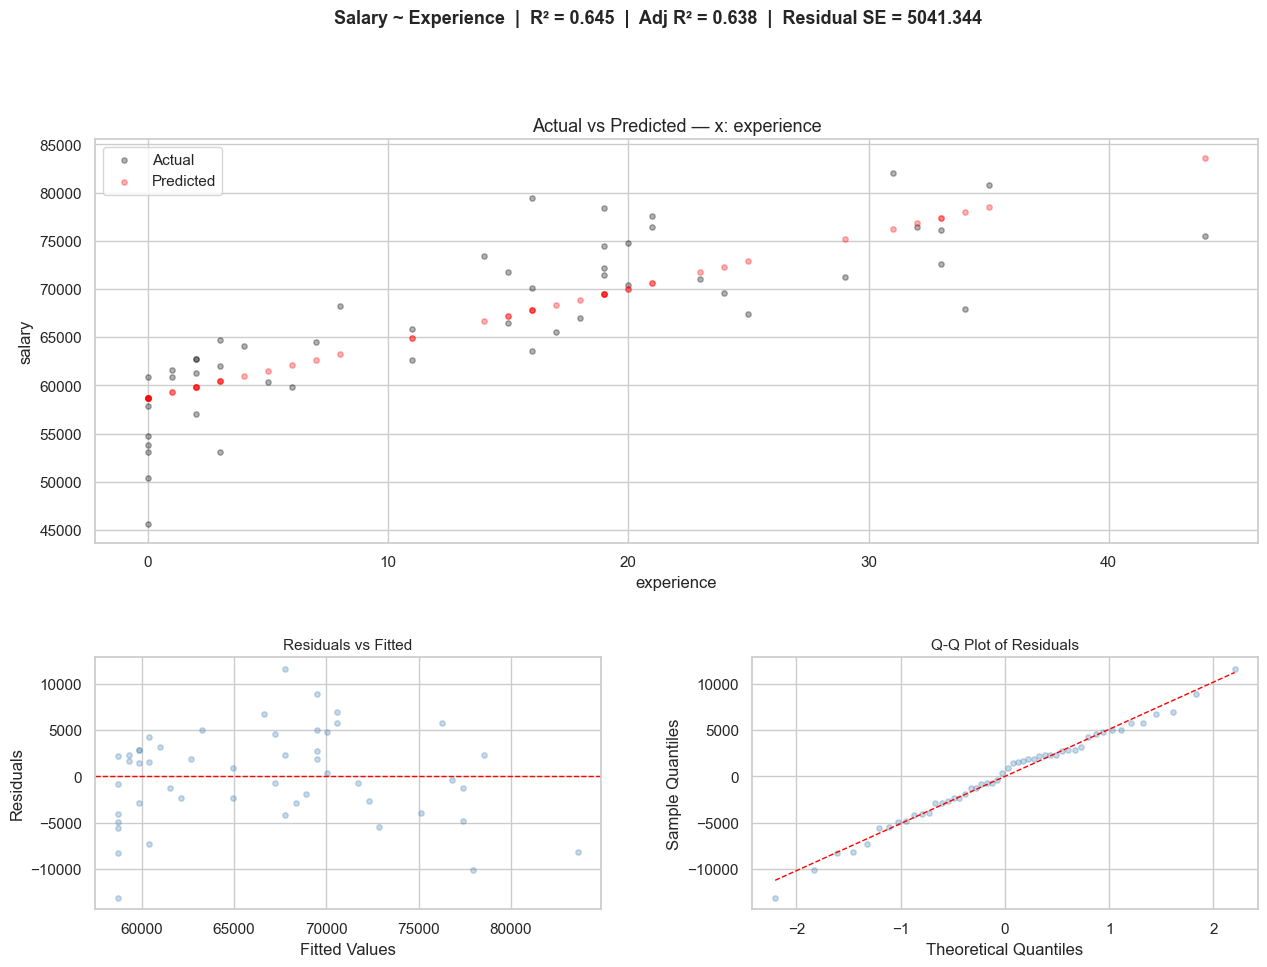

In [100]:
# --- Model 2: salary ~ experience ---
# A simple linear regression of salary on years of experience

model2 = fit_and_plot('salary ~ experience', 
                    data=winner, 
                    model_name='Salary ~ Experience', 
                    x_var='experience')

---
## 4. Salary on Gender + Experience

Extend the model to include both predictors. Does gender remain significant once we control for experience?


  Salary ~ Experience
  R²: 0.6474    Adj R²: 0.6324    Residual SE: 5078.0653
  Observations: 50    df residual: 47
-------------------------------------------------------
  Coefficient            Estimate    Std Err        t    P>|t|
-------------------------------------------------------
  Intercept            58573.9755  1140.4683   51.360   0.0000 ***
  gender[T.male]         983.2175  1770.7599    0.555   0.5814 
  experience             542.0658    75.2593    7.203   0.0000 ***



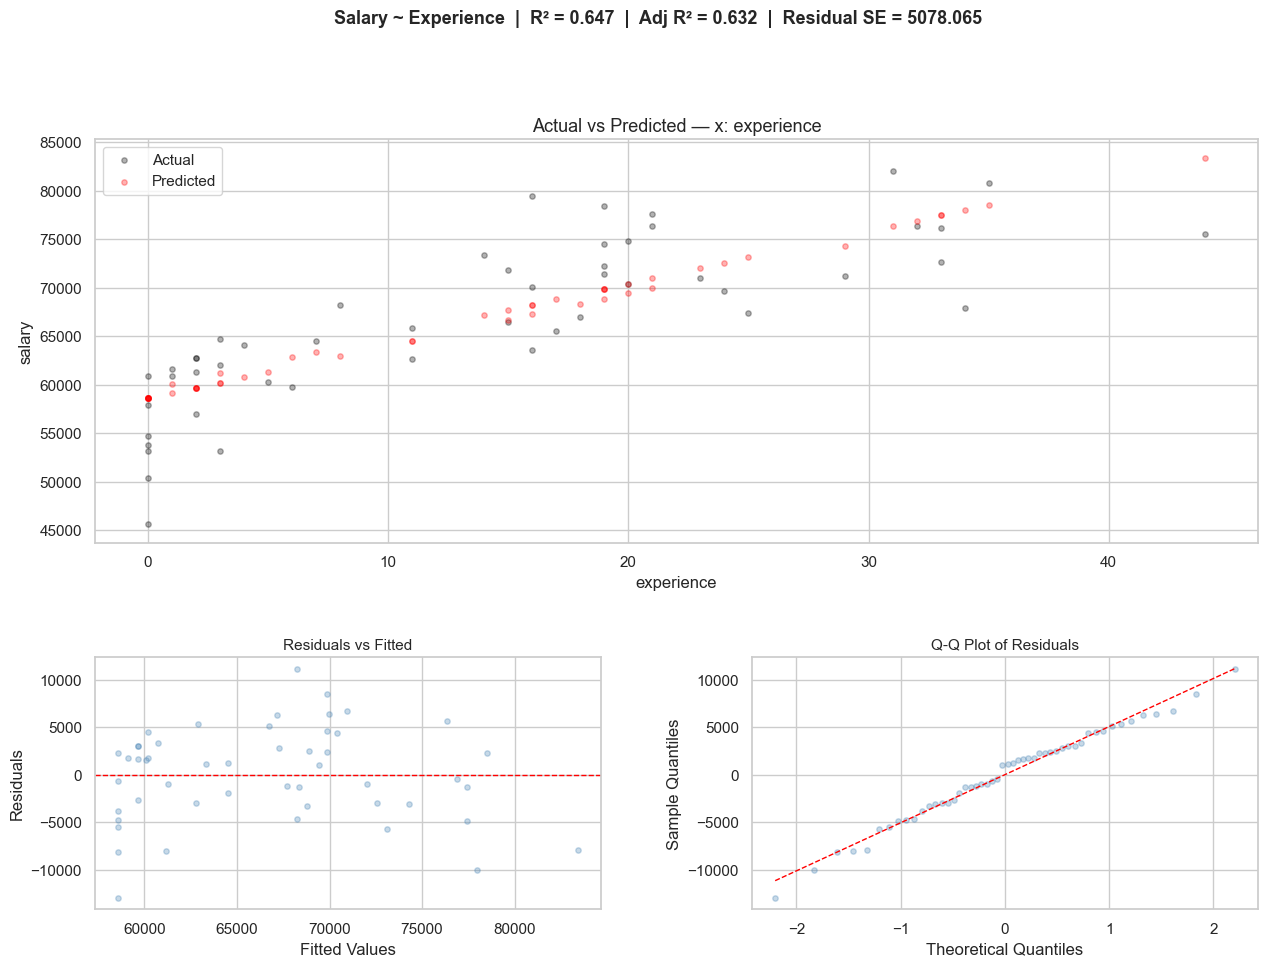

In [101]:
# --- Model 3: salary ~ experience + gender ---

model3 = fit_and_plot('salary ~ experience + gender', 
                    data=winner, 
                    model_name='Salary ~ Experience', 
                    x_var='experience')

---
## 5. Improving the Model — Non-linear Experience Effect

Someone at the meeting argued that salary increases **faster** in early career years than in later years. We check whether a square-root transformation of experience fits better.

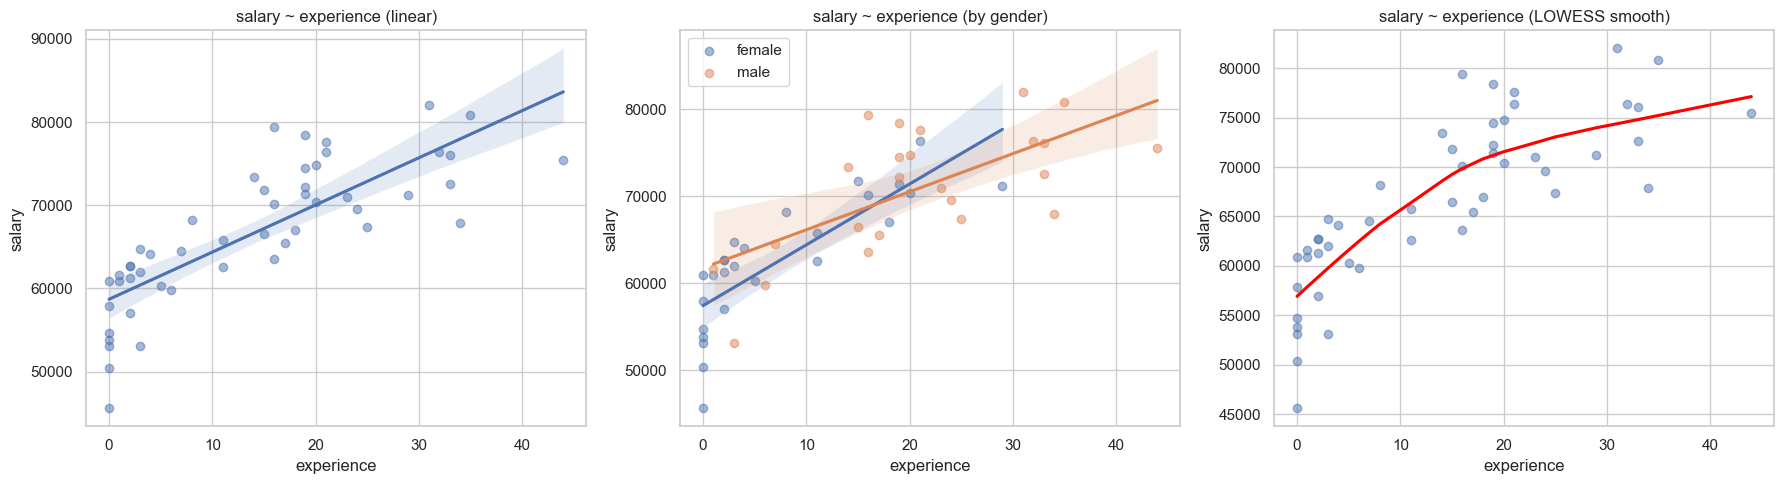

The LOWESS curve suggests salary grows quickly early on, then flattens — a sqrt() shape.


In [102]:
# --- Scatterplots with trend lines to visualise the shape of the relationship ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: linear trend (OLS)
sns.regplot(
    data=winner, x='experience', y='salary',
    ax=axes[0], scatter_kws={'alpha': 0.5}
)
axes[0].set_title('salary ~ experience (linear)')

# Panel 2: colour by gender with linear fit per group
for gender, grp in winner.groupby('gender'):
    sns.regplot(
        data=grp, x='experience', y='salary',
        ax=axes[1], label=gender,
        scatter_kws={'alpha': 0.5}
    )
axes[1].set_title('salary ~ experience (by gender)')
axes[1].legend()

# Panel 3: LOWESS smooth (non-parametric) to let the data suggest the shape
sns.regplot(
    data=winner, x='experience', y='salary',
    ax=axes[2],
    lowess=True,              # equivalent to geom_smooth(se=FALSE) in R
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)
axes[2].set_title('salary ~ experience (LOWESS smooth)')

plt.tight_layout()
plt.show()
print('The LOWESS curve suggests salary grows quickly early on, then flattens — a sqrt() shape.')


  Salary ~ Experience
  R²: 0.7403    Adj R²: 0.7292    Residual SE: 4358.0788
  Observations: 50    df residual: 47
-------------------------------------------------------
  Coefficient            Estimate    Std Err        t    P>|t|
-------------------------------------------------------
  Intercept            54759.0620  1196.2514   45.776   0.0000 ***
  C(gender)[T.male]      -73.4243  1533.2672   -0.048   0.9620 
  sqrt_experience       3713.7379   397.5891    9.341   0.0000 ***



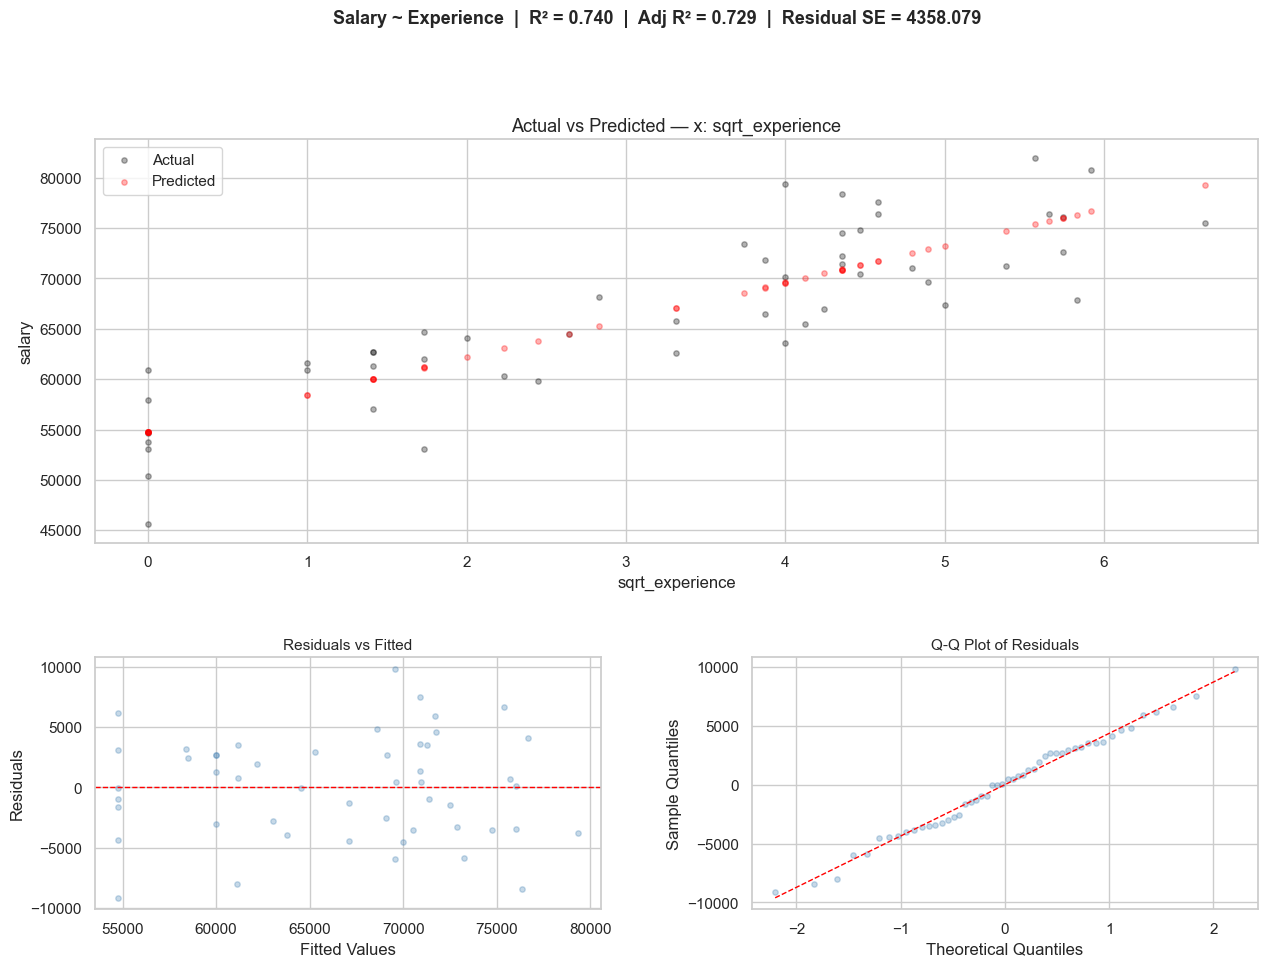

In [103]:
# --- Model 4: salary ~ sqrt(experience) + gender ---
# A sqrt() transformation lets the marginal effect of experience decrease over time

winner_aug = winner.assign(sqrt_experience=lambda df: np.sqrt(df['experience']))

model4 = fit_and_plot('salary ~ sqrt_experience + C(gender)', 
                    data=winner_aug, 
                    model_name='Salary ~ Experience', 
                    x_var='sqrt_experience')



  Salary ~ Experience
  R²: 0.7403    Adj R²: 0.7348    Residual SE: 4312.5484
  Observations: 50    df residual: 48
-------------------------------------------------------
  Coefficient            Estimate    Std Err        t    P>|t|
-------------------------------------------------------
  Intercept            54760.0484  1183.5782   46.267   0.0000 ***
  sqrt_experience       3702.4314   316.5508   11.696   0.0000 ***



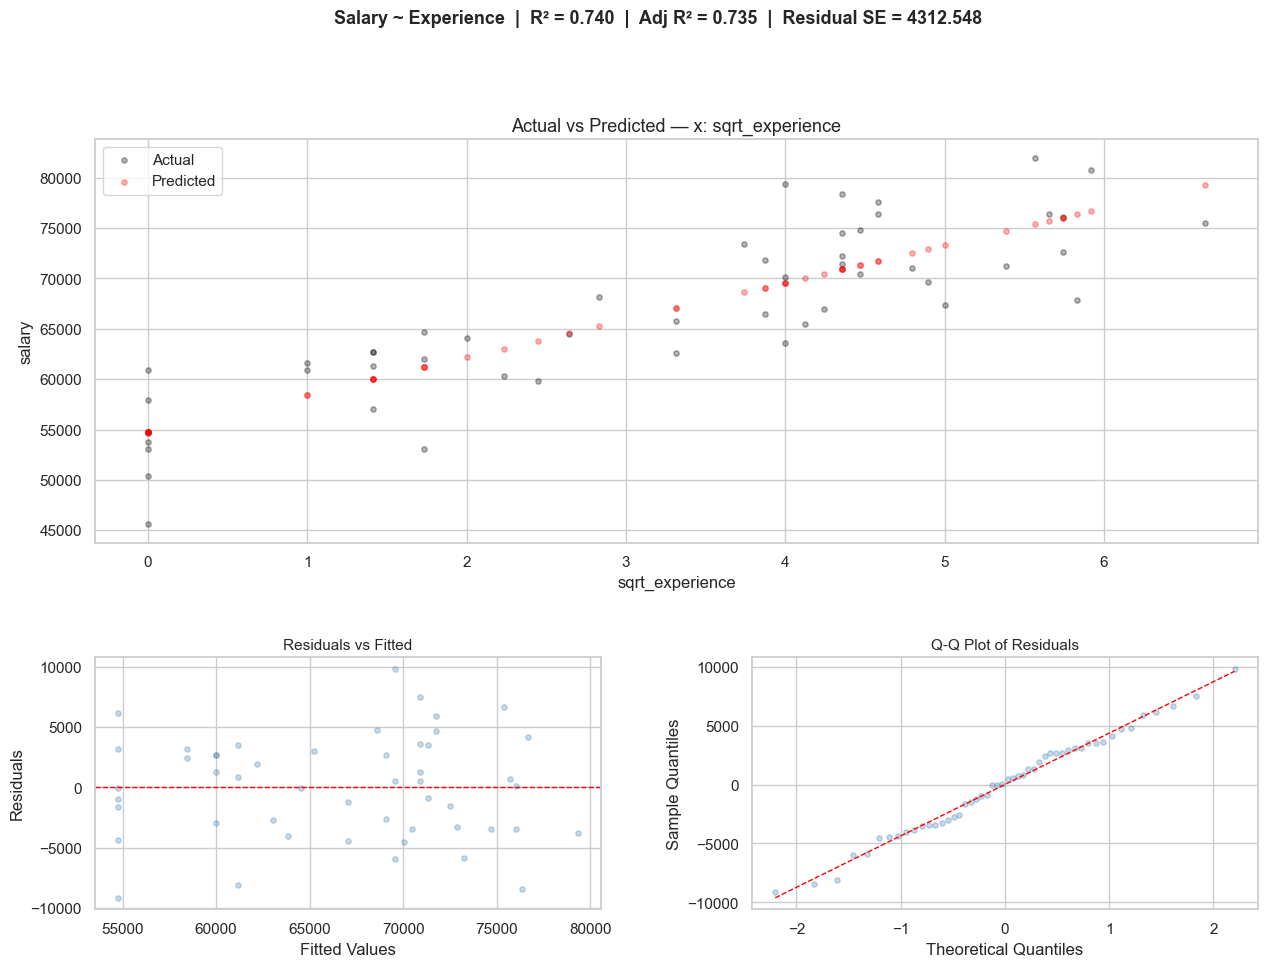

In [104]:
# --- Model 5: salary ~ sqrt(experience) — remove non-significant gender ---


model5 = fit_and_plot('salary ~ sqrt_experience', 
                    data=winner_aug, 
                    model_name='Salary ~ Experience', 
                    x_var='sqrt_experience')

In [105]:
# --- Model comparison table (equivalent to huxtable::huxreg) ---

models = {
    'M1: ~gender':         model1,
    'M2: ~exp':            model2,
    'M3: ~exp+gender':     model3,
    'M4: ~sqrt+gender':    model4,
    'M5: ~sqrt':           model5,
}

comparison = pd.DataFrame({
    name: {
        'N':              int(m.nobs),
        'R²':             round(m.rsquared, 4),
        'Adj. R²':        round(m.rsquared_adj, 4),
        'Residual SE':    round(np.sqrt(m.mse_resid), 0),
        'AIC':            round(m.aic, 1),
    }
    for name, m in models.items()
})

print('Model Comparison:')
comparison

Model Comparison:


,M1: ~gender,M2: ~exp,M3: ~exp+gender,M4: ~sqrt+gender,M5: ~sqrt
N,50.0000,50.0000,50.0000,50.0000,50.0000
R²,0.2581,0.6451,0.6474,0.7403,0.7403
Adj. R²,0.2427,0.6377,0.6324,0.7292,0.7348
Residual SE,7288.0000,5041.0000,5078.0000,4358.0000,4313.0000
AIC,1033.3000,996.4000,998.1000,982.8000,980.8000


---
## Conclusions

1. The raw salary gap (~£8,400) **is statistically significant** when gender alone is the predictor.
2. However, men in this sample have on average **~14 more years of experience** than women.
3. Once experience is included in the model, **gender is no longer statistically significant**.
4. The best-fitting model uses **√(experience)** as the predictor (Adj. R² is highest), confirming that salary growth decelerates with tenure.
5. **No evidence of discrimination** in this data, once experience differences are accounted for-- but it's a cheap argument